In [1]:
# Zelle 1: Imports, Service initialisieren, verfügbare Backends anzeigen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import time
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, SamplerOptions
from qiskit import transpile

# IBM Quantum Zugangsdaten hier einfügen
API_TOKEN = "hc_jCRxZWVqz8KZuZY58kmtbiC81I1tuGuKrU4a-VOGF"
CHANNEL = "ibm_quantum_platform"
INSTANCE = "crn:v1:bluemix:public:quantum-computing:us-east:a/71e0d8f4996f4919a7a1f5a17593eac9:817179d7-c733-47f0-89fa-64f2696e053c::"
service = QiskitRuntimeService(channel=CHANNEL, token=API_TOKEN, instance=INSTANCE)
print("IBM Quantum Service initialisiert ")

# Abfrage verfügbarer Backends
backends = service.backends()
print("Gefundene Backends für deinen Account:")
for b in backends:
    status = "aktiv" if b.status().operational else "down"
    sim = " (Simulator)" if b.configuration().simulator else ""
    print(f"- {b.name}{sim} | {status}")


IBM Quantum Service initialisiert 
Gefundene Backends für deinen Account:
- ibm_torino | aktiv
- ibm_brisbane | aktiv


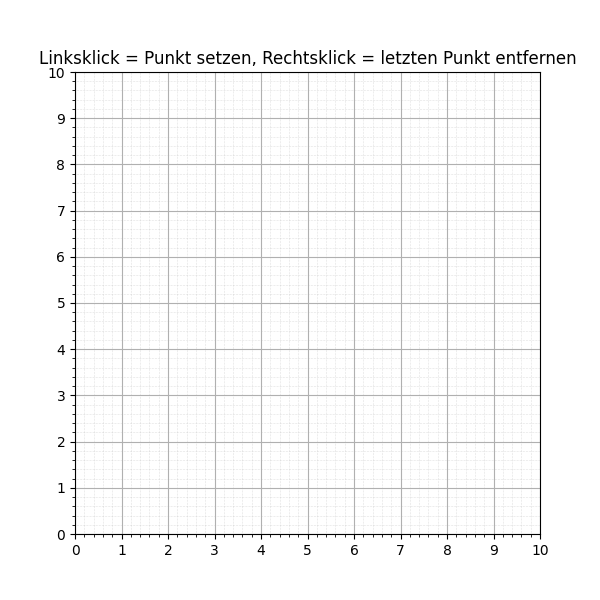

Punkte-Setzen aktiviert. Punkte werden in 'points' gespeichert.


In [2]:
%matplotlib widget

import matplotlib.ticker as ticker

points = []

fig, ax = plt.subplots(figsize=(6,6))
ax.set_title("Linksklick = Punkt setzen, Rechtsklick = letzten Punkt entfernen")
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.grid(True, which='major', linestyle='-', linewidth=0.8)
ax.grid(True, which='minor', linestyle=':', linewidth=0.4, alpha=0.7)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.2))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.2))

scat = ax.scatter([], [])

def onclick(event):
    global points, scat
    if event.inaxes != ax:
        return
    if event.button == 1:
        points.append((event.xdata, event.ydata))
    elif event.button == 3:
        if points:
            points.pop()
    if points:
        xs, ys = zip(*points)
    else:
        xs, ys = [], []
    scat.set_offsets(list(zip(xs, ys)))
    fig.canvas.draw()

cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.show()

print("Punkte-Setzen aktiviert. Punkte werden in 'points' gespeichert.")


In [3]:
# (Optional) IBM Quantum Zugangsdaten (wenn nicht in Zelle 1)

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel=CHANNEL, token=API_TOKEN, instance=INSTANCE)
print("IBM Quantum Service initialisiert ")


IBM Quantum Service initialisiert 


In [4]:
# Zelle 3: Hilfsfunktionen für TSP mit Priorität und Zeitmatrix


def time_matrix_from_coords(xy):
    n = len(xy)
    m = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                m[i, j] = np.linalg.norm(xy[i] - xy[j]) * 10.0
    return m

def create_tsp_with_priority(time_matrix, prioritized_idx, deadline_visit):
    n = time_matrix.shape[0]
    qp = QuadraticProgram("tsp_priority")

    # Entscheidungsvariablen x_i_j: Stadt i besucht an Position j
    for i in range(n):
        for j in range(n):
            if i != j:
                qp.binary_var(f"x_{i}_{j}")

    # MTZ-Variablen u_i für Subtouren-Vermeidung
    for i in range(1, n):
        qp.integer_var(1, n - 1, f"u_{i}")

    # Ziel: Gesamtzeit minimieren
    linear = {f"x_{i}_{j}": float(time_matrix[i, j]) for i in range(n) for j in range(n) if i != j}
    qp.minimize(linear=linear)

    # Jede Stadt genau einmal verlassen (außer Depot?)
    for i in range(n):
        qp.linear_constraint(
            sense="==",
            rhs=1,
            linear={f"x_{i}_{j}": 1 for j in range(n) if i != j},
            name=f"leave_{i}"
        )

    # Jede Stadt genau einmal ankommen
    for j in range(n):
        qp.linear_constraint(
            sense="==",
            rhs=1,
            linear={f"x_{i}_{j}": 1 for i in range(n) if i != j},
            name=f"enter_{j}"
        )

    # MTZ Subtour Prevention Constraints
    for i in range(1, n):
        for j in range(1, n):
            if i != j:
                qp.linear_constraint(
                    sense="<=",
                    rhs=n - 2,
                    linear={f"u_{i}": 1, f"u_{j}": -1, f"x_{i}_{j}": n - 1},
                    name=f"mtz_{i}_{j}"
                )

    qp.linear_constraint(
        sense="<=",
        rhs=deadline_visit,
        linear={f"u_{prioritized_idx}": 1},
        name="priority_deadline"
    )

    return qp


In [5]:
# Zelle 4: Das hier führt alles zusammen, muss bei jeder Punkteänderung erneut ausgeführt werden

if len(points) < 2:
    print("Bitte mindestens 2 Punkte setzen!")
else:
    coords = np.array(points)

    # Beispiel Priorisierung (hier erste Stadt nach Depot)
    prioritized_idx = 1 if len(coords) > 1 else 0
    deadline_visit = 15

    time_matrix = time_matrix_from_coords(coords)

    # TSP QuadraticProgram erzeugen mit aktuellen coords
    qp = create_tsp_with_priority(time_matrix, prioritized_idx, deadline_visit)

    # QUBO-Konvertierung & Ising-Operator
    qubo = QuadraticProgramToQubo().convert(qp)
    ising_op, offset = qubo.to_ising()

    # QAOA vorbereiten & Circuit erzeugen
    reps = 1
    qaoa = QAOAAnsatz(ising_op, reps=reps)
    qc_param = qaoa.decompose()
    qc = qc_param.assign_parameters([0.7] * len(qc_param.parameters))

    qc = qc_param.assign_parameters([0.7] * len(qc_param.parameters))

# Messungen hinzufügen, falls noch keine vorhanden sind
if not qc.clbits:
    qc.measure_all()

print(f"QAOA Circuit erzeugt mit {qc.num_qubits} Qubits für {len(points)} Punkte.")



QAOA Circuit erzeugt mit 129 Qubits für 6 Punkte.


In [6]:
# Zelle 5: Job ausführen und auf Abschluss warten

BACKEND = "ibm_torino"  # nach Belieben anpassen

backend_obj = service.backend(BACKEND)
qc_transpiled = transpile(qc, backend=backend_obj)

sampler = Sampler(mode=backend_obj, options=SamplerOptions(default_shots=1024))
print(f"Job an {BACKEND} senden...")

job = sampler.run([qc_transpiled])
print("Job-ID:", job.job_id())

print("Warte auf Abschluss...")
while job.status() not in ['DONE', 'CANCELLED', 'ERROR']:
    print(f"Aktueller Status: {job.status()}")
    time.sleep(10)

print(f"Job beendet mit Status: {job.status()}")


Job an ibm_torino senden...
Job-ID: d2neph8hsgmc73b6srg0
Warte auf Abschluss...
Aktueller Status: RUNNING
Job beendet mit Status: DONE


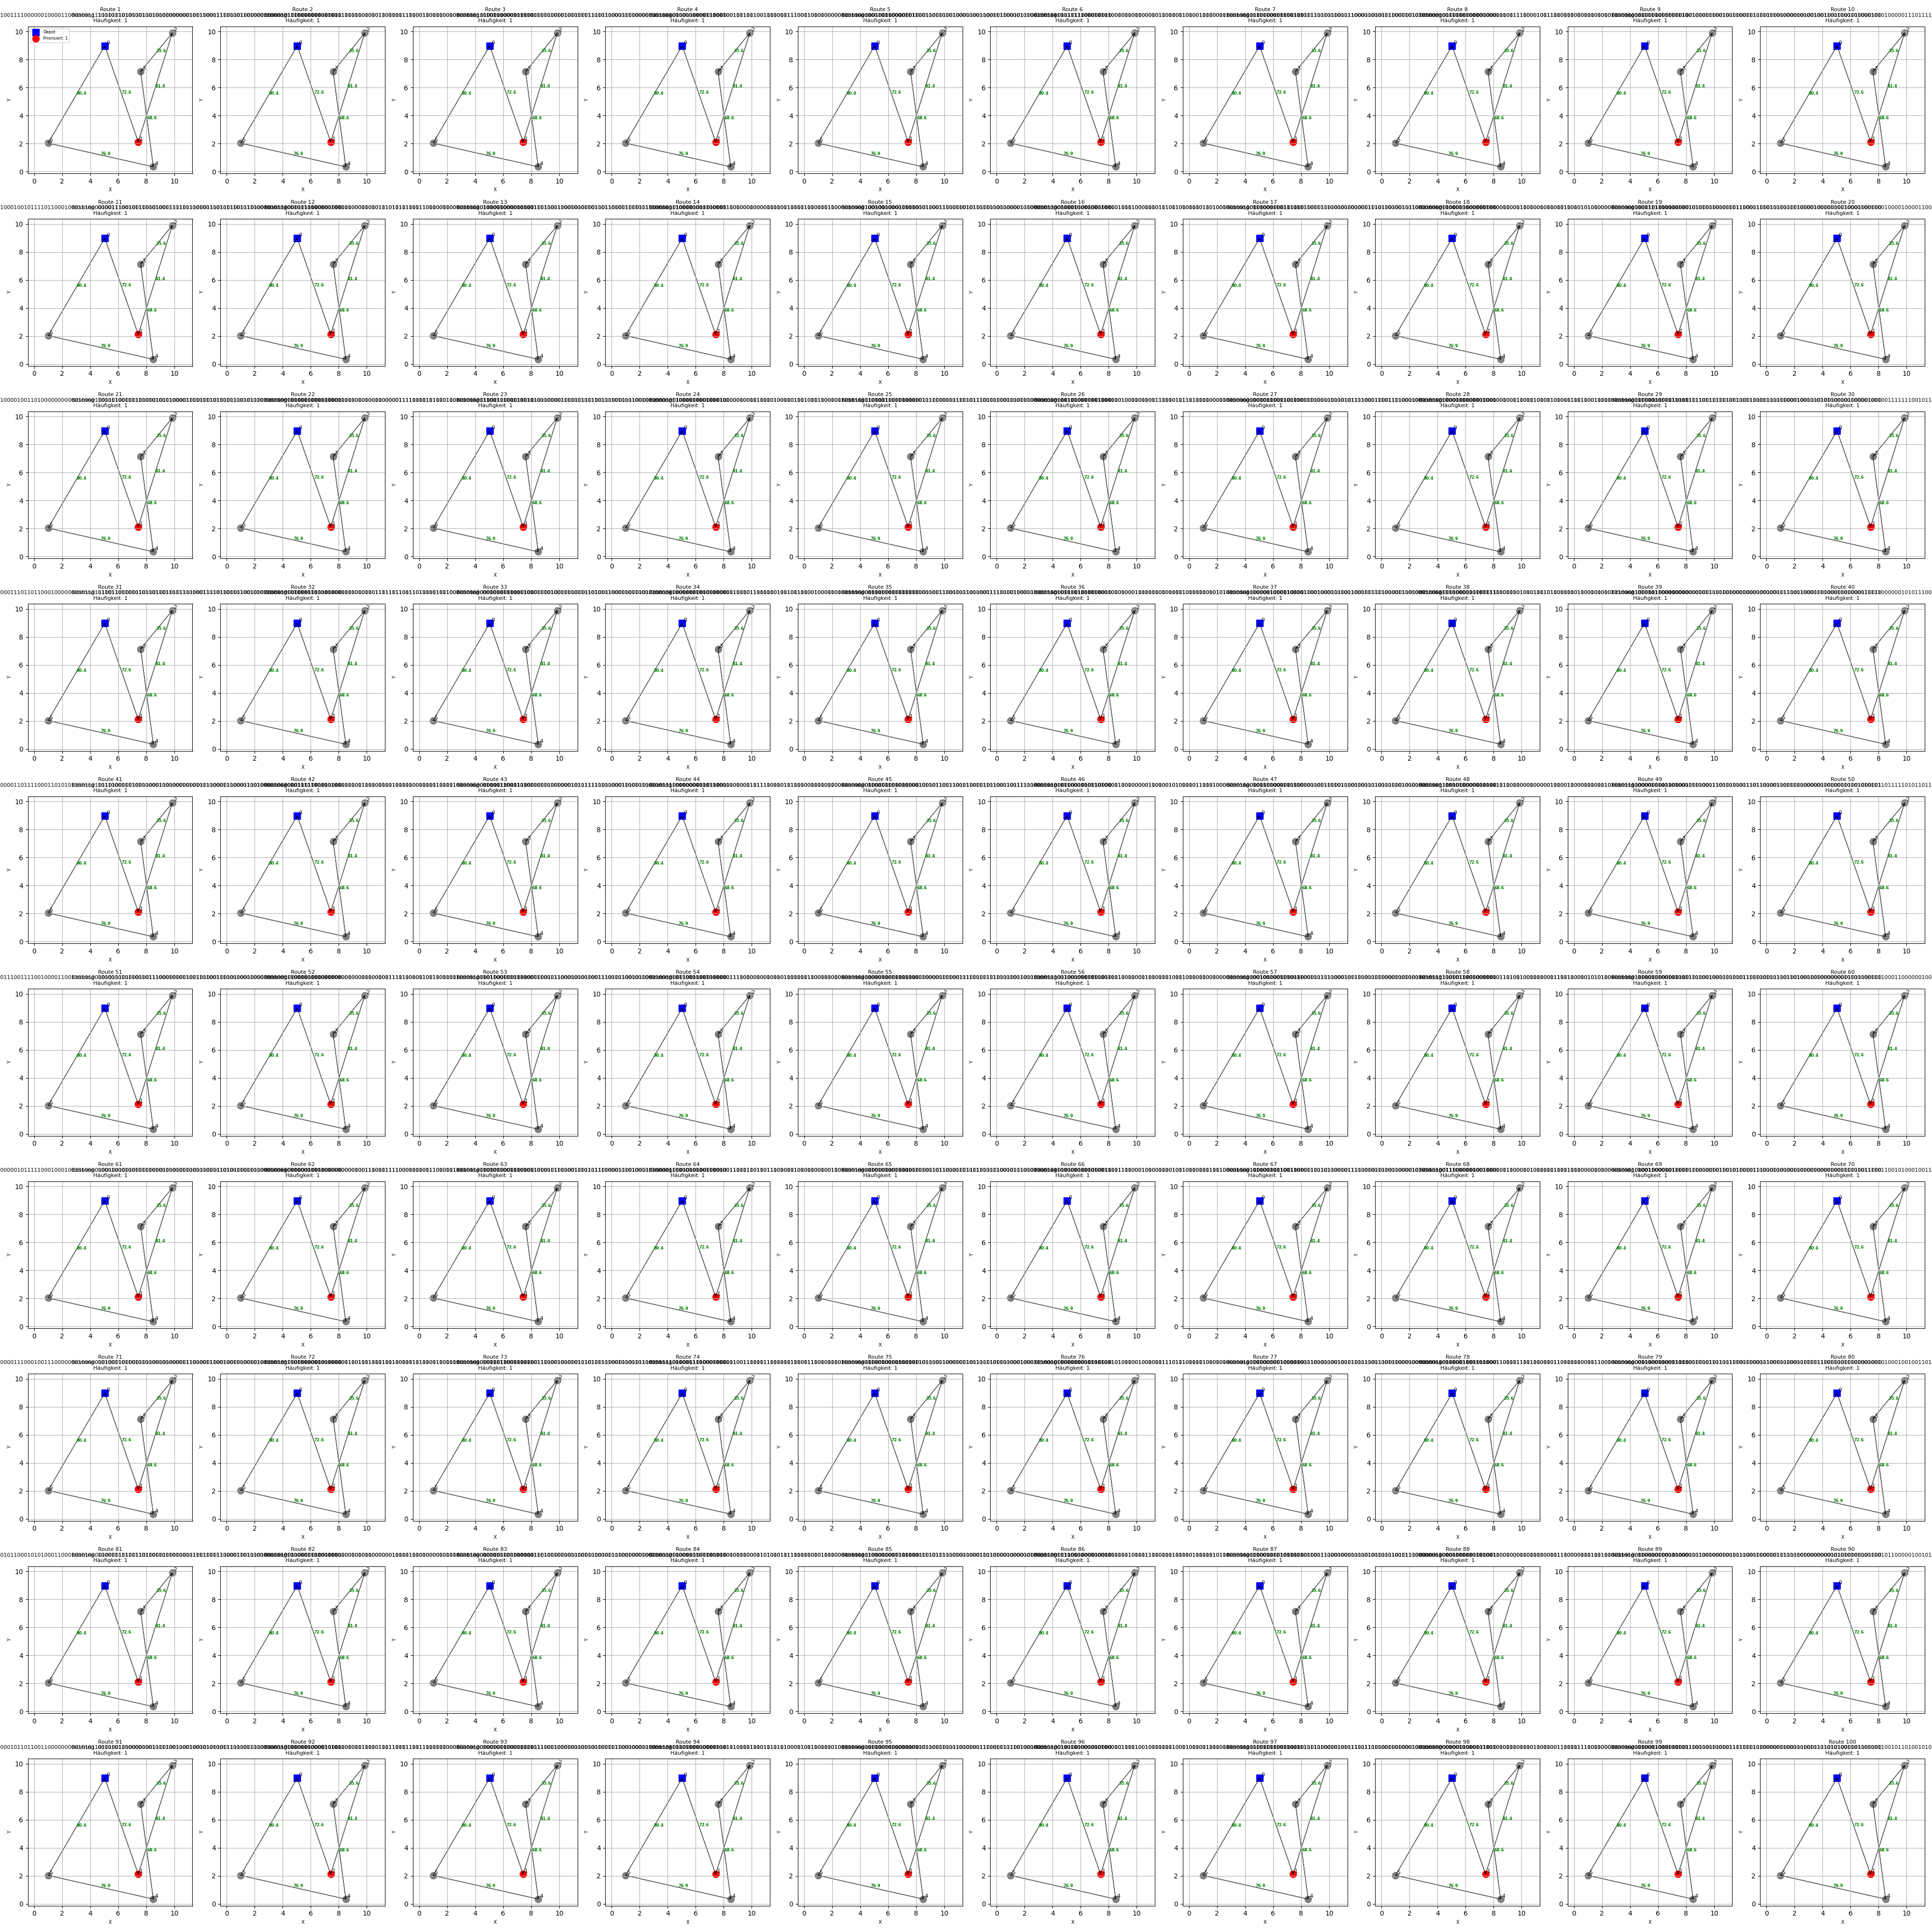

In [ ]:
# Zelle 6: Ergebnisse auswerten

import math

# Anzahl der Plots insgesamt
top_k = 100

# Anzahl der Spalten für das Grid (z.B. 10)
cols = 10

# Anzahl der notwendigen Reihen berechnen
rows = math.ceil(top_k / cols)

# Figurgröße dynamisch anpassen (Breite: 4 pro Plot, Höhe: 4 pro Reihe)
fig_width = 4 * cols
fig_height = 4 * rows

plt.figure(figsize=(fig_width, fig_height))

for idx, row in enumerate(most_common.itertuples()):
    bitstr = row.bitstring
    cnt = row.count
    route = bitstring_to_route(bitstr, len(coords))

    # Subplot an der Position im Grid (Zeile, Spalte)
    plt.subplot(rows, cols, idx + 1)

    x = coords[:, 0]
    y = coords[:, 1]
    route_array = np.array(route)

    plt.scatter(x, y, c="gray", s=100)
    plt.scatter(x[0], y[0], c="blue", s=100, marker="s", label="Depot")
    plt.scatter(x[prioritized_idx], y[prioritized_idx], c="red", s=100, marker="o", label=f"Priorisiert: {prioritized_idx}")

    for i in range(len(route_array) - 1):
        start = route_array[i]
        end = route_array[i + 1]
        plt.arrow(x[start], y[start], x[end] - x[start], y[end] - y[start],
                  head_width=0.1, length_includes_head=True, color="black", alpha=0.6)
        dist = time_matrix[start, end]
        mid_x = (x[start] + x[end]) / 2
        mid_y = (y[start] + y[end]) / 2
        plt.text(mid_x, mid_y, f"{dist:.1f}", color="green", fontsize=6, weight="bold")

    for i in range(len(coords)):
        plt.text(x[i] + 0.1, y[i] + 0.1, str(i), fontsize=8)

    plt.title(f"Route {idx + 1}\nBitstring: {bitstr}\nHäufigkeit: {cnt}", fontsize=8)
    plt.xlabel("X", fontsize=7)
    plt.ylabel("Y", fontsize=7)
    plt.grid(True)
    plt.axis("equal")
    if idx == 0:
        plt.legend(fontsize=6)

plt.tight_layout()
plt.show()


Alle 1024 gemessenen Bitstrings samt Häufigkeit und Wahrscheinlichkeit gespeichert.


C:\Users\juanc\AppData\Local\Temp\ipykernel_33404\202435174.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


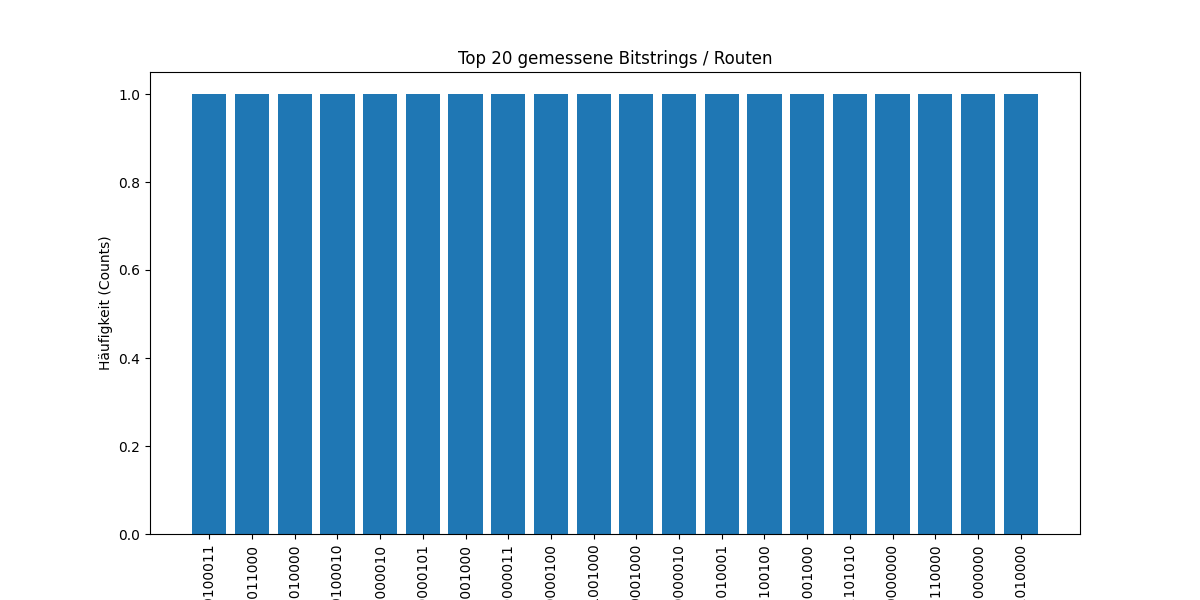

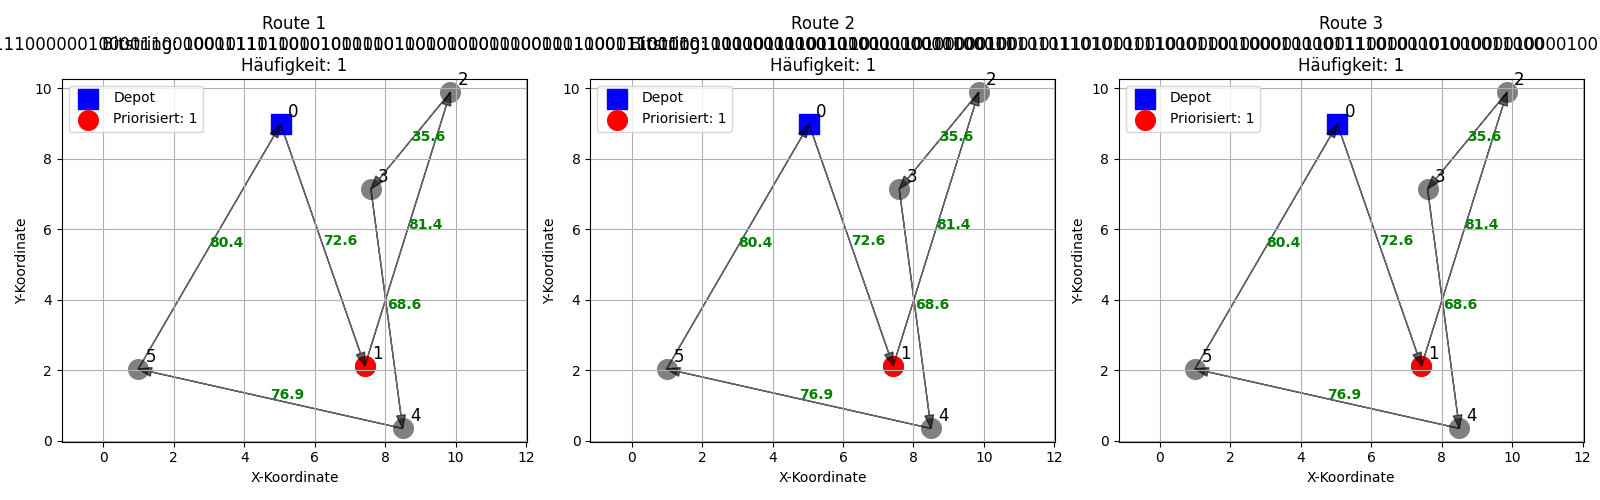

In [14]:
# Zelle 7a: Analyse- und Speicherzelle

import pandas as pd
import matplotlib.pyplot as plt

# Annahme: counts wurde aus dem Job korrekt ermittelt (wie in vorheriger Zelle)
# counts = {bitstring: Häufigkeit, ...}

# 1. Komplette Verteilung in DataFrame
df_counts = pd.DataFrame(list(counts.items()), columns=['bitstring', 'count'])
df_counts['probability'] = df_counts['count'] / df_counts['count'].sum()

# Speichern aller Messdaten in CSV
df_counts.to_csv("SmallerRoutingOnIBM_full_distributionIII.csv", index=False)
print(f"Alle {len(df_counts)} gemessenen Bitstrings samt Häufigkeit und Wahrscheinlichkeit gespeichert.")

# 2. Balkendiagramm der Top 20 Bitstrings nach Häufigkeit
top_n = 20
top_counts = df_counts.sort_values('count', ascending=False).head(top_n)
plt.figure(figsize=(12,6))
plt.bar(range(top_n), top_counts['count'], tick_label=top_counts['bitstring'])
plt.xticks(rotation=90)
plt.xlabel("Bitstring (Route)")
plt.ylabel("Häufigkeit (Counts)")
plt.title(f"Top {top_n} gemessene Bitstrings / Routen")
plt.tight_layout()
plt.show()

# 3. Top 3 unterschiedliche Routen plotten (wie zuvor) mit angepasstem Mapping

def bitstring_to_route(bitstring, num_nodes):
    # Hier Anpassung an dein Bitstring-zu-Route Mapping notwendig!
    # Platzhalter-Beispiel; du musst deine Logik hier implementieren
    # Beispiel: Einfach numerische Reihenfolge
    return list(range(num_nodes)) + [0]

top_k = 3
most_common = df_counts.sort_values('count', ascending=False).head(top_k)

plt.figure(figsize=(16,5))
for idx, row in enumerate(most_common.itertuples()):
    bitstr = row.bitstring
    count = row.count
    route = bitstring_to_route(bitstr, coords.shape[0])
    
    plt.subplot(1, top_k, idx+1)
    x = coords[:, 0]
    y = coords[:, 1]
    route_array = np.array(route)

    # Punkte
    plt.scatter(x, y, c="gray", s=200)
    plt.scatter(x[0], y[0], c="blue", s=200, marker="s", label="Depot")
    plt.scatter(x[prioritized_idx], y[prioritized_idx], c="red", s=200, marker="o", label=f"Priorisiert: {prioritized_idx}")

    # Route als Pfeile
    for i in range(len(route_array)-1):
        start = route_array[i]
        end = route_array[i+1]
        plt.arrow(x[start], y[start], x[end]-x[start], y[end]-y[start],
                  head_width=0.25, length_includes_head=True, color="black", alpha=0.6)
        dist = time_matrix[start, end]
        mid_x = (x[start] + x[end]) / 2
        mid_y = (y[start] + y[end]) / 2
        plt.text(mid_x, mid_y, f"{dist:.1f}", color="green", fontsize=10, weight="bold")
    
    # Punktnummern
    for i in range(len(coords)):
        plt.text(x[i]+0.2, y[i]+0.2, str(i), fontsize=12)

    plt.title(f"Route {idx+1}\nBitstring: {bitstr}\nHäufigkeit: {count}")
    plt.xlabel("X-Koordinate")
    plt.ylabel("Y-Koordinate")
    plt.grid(True)
    plt.axis("equal")
    plt.legend()

plt.tight_layout()
plt.show()


In [15]:
# Zelle 8: Einzelfall-Plot für spezielle Route

def plot_route(route, coords, time_matrix, prioritized_idx=0, title="Route Plot"):
    import matplotlib.pyplot as plt
    import numpy as np

    x = coords[:, 0]
    y = coords[:, 1]
    route_array = np.array(route)
    plt.figure(figsize=(10,8))
    plt.scatter(x, y, c="gray", s=200)
    plt.scatter(x[0], y[0], c="blue", s=200, marker="s", label="Depot")
    plt.scatter(x[prioritized_idx], y[prioritized_idx], c="red", s=200, marker="o", label=f"Priorisiert: {prioritized_idx}")
    for i in range(len(route_array)-1):
        start = route_array[i]
        end = route_array[i+1]
        plt.arrow(x[start], y[start], x[end]-x[start], y[end]-y[start], 
                  head_width=0.25, length_includes_head=True, color="black", alpha=0.6)
        dist = time_matrix[start, end]
        mid_x = (x[start] + x[end]) / 2
        mid_y = (y[start] + y[end]) / 2
        plt.text(mid_x, mid_y, f"{dist:.1f}", color="green", fontsize=10, weight="bold")
    for i in range(len(coords)):
        plt.text(x[i]+0.2, y[i]+0.2, str(i), fontsize=12)
    plt.title(title)
    plt.xlabel("X-Koordinate")
    plt.ylabel("Y-Koordinate")
    plt.grid(True)
    plt.axis("equal")
    plt.legend()
    sav.figure("SmallerRouteOnIBM_III.png")
    plt.show()

# Beispielaufruf
# plot_route(bitstring_to_route(most_common[0][0], coords.shape[0]), coords, time_matrix, prioritized_idx)


In [ ]:
# Zelle 9: Speichern oder weitere Auswertungen

routes_table.to_csv("SmallerRoutingOnIBM_routes_statsIII.csv", index=False)
print("Routenstatistik in 'SmallerRoutingOnIBM_routes_statsIII.csv' gespeichert.")


NameError: name 'routes_table' is not defined